# Google Colab Lab Assignment - Pretrained Model

**Course Name:** Generative AI LAB

**Lab Title:** Research Paper Implementation with Pre-trained Model — Handwritten Digit (0–9) Classification using CNN and Transfer Learning (VGG16)

**Student Name:** NIKHEEL C KHADAKABHAVI

**Student ID:** 202401110020

**Date of Submission:** 25-08-2026

**Group Members:** GUNJAN BALAPURE

**Reference Paper:** *A Comparative Study of Custom CNNs, Pre-trained Models, and Transfer Learning Across Multiple Visual Datasets* (`arXiv:2601.02246`)

**Dataset:** Handwritten Digits 0–9 (Kaggle) — a folder-per-class image dataset with 10 folders (`0` … `9`), each containing handwritten digit images for that class.
Dataset link: **[Paste the Kaggle dataset link here]**

---

## Instructions

1. Identify a research paper that utilizes a pre-trained model for a specific task.
2. Study the methodology, dataset, and model used in the research paper.
3. Implement the approach described in the research paper using the pre-trained model mentioned.
4. Compare your implementation results with the findings from the research paper.

---

## Objective

1. Study a research paper utilizing a pre-trained model.
2. Reproduce the model implementation using a dataset and methodology similar to the research paper (here: handwritten digit images 0–9).
3. Fine-tune the pre-trained model (VGG16) and optimize hyperparameters.
4. Evaluate and compare model performance with a custom CNN, a frozen pre-trained model, and a fine-tuned pre-trained model — and relate the results back to the research paper's findings.

---

## Research Paper Summary

- **Title:** *A Comparative Study of Custom CNNs, Pre-trained Models, and Transfer Learning Across Multiple Visual Datasets*
- **Problem:** The paper investigates which CNN learning strategy gives the best trade-off between accuracy and computational cost: (a) a custom CNN trained from scratch, (b) a pre-trained CNN used as a frozen feature extractor, or (c) a pre-trained CNN fine-tuned on the target dataset.
- **Methodology:** The paper compares a custom CNN, a frozen VGG16/MobileNetV2 feature extractor, and a fine-tuned VGG16/MobileNetV2 model, using identical data splits, preprocessing, and evaluation metrics for a fair comparison.
- **Evaluation:** Accuracy, precision, recall, F1-score, training time, and parameter counts.
- **Key Finding:** Transfer learning (fine-tuning) generally achieves the strongest predictive performance, while the custom CNN offers a better efficiency-to-accuracy trade-off.
- **Relevance to this practical:** This notebook follows the same three-model comparison methodology from the paper, applied to a real, locally-downloaded **Handwritten Digits (0–9)** image dataset instead of a synthetic benchmark.

## Task 1: Research Paper Selection and Dataset Preparation

**Instructions:**

1. Select a research paper that applies a pre-trained model (here: **VGG16**).
2. Dataset used: **Handwritten Digits 0–9** (Kaggle), organized as one folder per class:

```
handwritten-digits-0-9/
│
├── 0/
├── 1/
├── 2/
├── 3/
├── 4/
├── 5/
├── 6/
├── 7/
├── 8/
└── 9/
```

3. Preprocessing performed below:
   - Images are resized to a fixed size so they match the model's expected input.
   - Images are converted to 3 channels and normalized using ImageNet statistics (required for the pre-trained VGG16 weights to work correctly).
4. The dataset is split into **Training (70%)**, **Validation (15%)**, and **Testing (15%)** sets.

In [1]:
# If a library is missing, uncomment and run this line (e.g. in Google Colab):
# !pip install torch torchvision matplotlib pandas scikit-learn

In [2]:
!pip install -q kagglehub

In [3]:
%matplotlib inline

import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision import models, datasets
from torch.utils.data import DataLoader, random_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("Libraries imported successfully")

Libraries imported successfully


In [4]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


### Dataset Loading and Preprocessing

In [5]:
import kagglehub

path = kagglehub.dataset_download("olafkrastovski/handwritten-digits-0-9")

print("Dataset downloaded to:", path)

100%|██████████| 66.7M/66.7M [00:00<00:00, 120MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/olafkrastovski/handwritten-digits-0-9/versions/2


In [6]:
import os

print(os.listdir(path))

['3', '2', '8', '7', '0', '9', '6', '1', '4', '5']


In [7]:
# from google.colab import drive
# drive.mount('/content/drive')

In [8]:
# ---------------------------------------------------------------
# IMPORTANT: point this to the folder that contains the 10
# sub-folders (0, 1, 2, ..., 9) of digit images.
#
# Example (Google Colab, after uploading/extracting the dataset):
#   DATA_DIR = "/content/handwritten-digits-0-9"
#
# Example (running locally, notebook placed next to the dataset folder):
#   DATA_DIR = "handwritten-digits-0-9"
# ---------------------------------------------------------------

DATA_DIR = path

IMG_SIZE = 64      # every image is resized to IMG_SIZE x IMG_SIZE
BATCH_SIZE = 32

# VGG16 was trained on 3-channel ImageNet images, so every digit
# image (even if it is grayscale) is converted to 3 channels and
# normalized with the ImageNet mean/std so the pre-trained weights
# behave correctly.
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# ImageFolder automatically uses each sub-folder name (0-9) as the class label
full_dataset = datasets.ImageFolder(root=DATA_DIR, transform=transform)
classes = full_dataset.classes

print("Classes found:", classes)
print("Total number of images:", len(full_dataset))

Classes found: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
Total number of images: 21555


In [9]:
# Split the dataset into Train (70%), Validation (15%), Test (15%)
total_size = len(full_dataset)
train_size = int(0.70 * total_size)
val_size   = int(0.15 * total_size)
test_size  = total_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(SEED)
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print("Training images:  ", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Testing images:   ", len(test_dataset))

Training images:   15088
Validation images: 3233
Testing images:    3234


### Visualize Sample Images

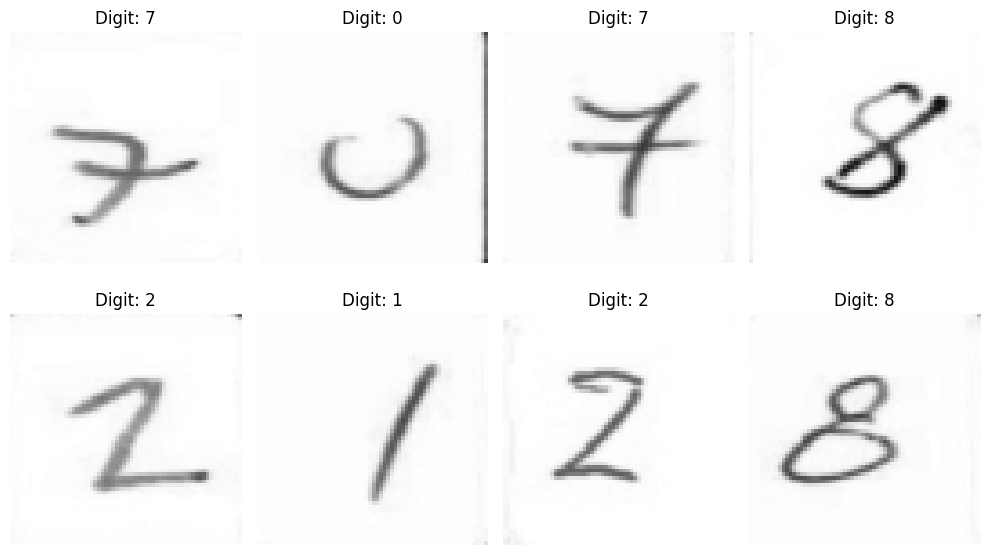

In [10]:
def denormalize(image_tensor):
    """Convert a normalized (C, H, W) tensor back into a viewable (H, W, C) image."""
    image = image_tensor.clone()
    for channel, mean, std in zip(image, IMAGENET_MEAN, IMAGENET_STD):
        channel.mul_(std).add_(mean)
    image = image.permute(1, 2, 0).numpy()
    return np.clip(image, 0, 1)

images, labels = next(iter(train_loader))

plt.figure(figsize=(10, 6))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(denormalize(images[i]))
    plt.title(f"Digit: {classes[labels[i].item()]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

## Task 2: Model Implementation and Fine-tuning

**Instructions:**

1. Implement the pre-trained model (VGG16) as described in the research paper, alongside a custom CNN baseline.
2. Visualize feature maps of a few early layers.
3. Freeze the initial (early) layers and fine-tune the top (late) layers according to the paper's methodology.
4. Optimize hyperparameters: learning rate, batch size, number of epochs, optimizer choice.
5. Three models are implemented below so they can be fairly compared, matching the research paper's methodology:
   - **Part A — Custom CNN:** trained completely from scratch.
   - **Part B — Frozen VGG16:** pre-trained convolutional layers are frozen and used only as a fixed feature extractor.
   - **Part C — Fine-Tuned VGG16:** pre-trained convolutional layers are mostly frozen, but the last convolutional block is unfrozen and fine-tuned on our digit dataset.

### Part A: Custom CNN (trained from scratch)

In [11]:
class CustomCNN(nn.Module):
    """A small CNN trained completely from scratch (no pre-trained weights)."""
    def __init__(self, num_classes=10):
        super(CustomCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

custom_cnn = CustomCNN(num_classes=len(classes)).to(device)
print(custom_cnn)

CustomCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=128, out_features=

### Part B: Pre-trained VGG16 as a Fixed Feature Extractor
All convolutional (feature) layers are frozen (`requires_grad = False`). Only the final classification layer is trained for our 10 digit classes.

In [12]:
# Load VGG16 pre-trained on ImageNet
frozen_vgg = models.vgg16(weights=models.VGG16_Weights.DEFAULT)

# Freeze all convolutional (feature-extraction) layers so their
# weights are NOT updated during training.
for param in frozen_vgg.features.parameters():
    param.requires_grad = False

# Replace the final classifier layer to match our 10 digit classes
frozen_vgg.classifier[6] = nn.Linear(frozen_vgg.classifier[6].in_features, len(classes))

frozen_vgg = frozen_vgg.to(device)
print("Frozen VGG16 (feature extractor) ready")

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:04<00:00, 134MB/s]


Frozen VGG16 (feature extractor) ready


### Part C: Fine-Tuned VGG16 Transfer Learning
The model starts with ImageNet pre-trained weights. Early layers stay frozen, while the final convolutional block (`[-6:]`) and the classifier are fine-tuned on our digit dataset.

In [13]:
finetune_vgg = models.vgg16(weights=models.VGG16_Weights.DEFAULT)

# Freeze all layers first...
for param in finetune_vgg.features.parameters():
    param.requires_grad = False

# ...then unfreeze the last convolutional block so it can adapt
# to our handwritten digit dataset (fine-tuning).
for param in list(finetune_vgg.features.parameters())[-6:]:
    param.requires_grad = True

finetune_vgg.classifier[6] = nn.Linear(finetune_vgg.classifier[6].in_features, len(classes))

finetune_vgg = finetune_vgg.to(device)
print("Fine-Tuned VGG16 ready")

Fine-Tuned VGG16 ready


### Feature Map Visualization
This shows how an early VGG16 convolutional layer converts one of our digit images into several learned feature maps.

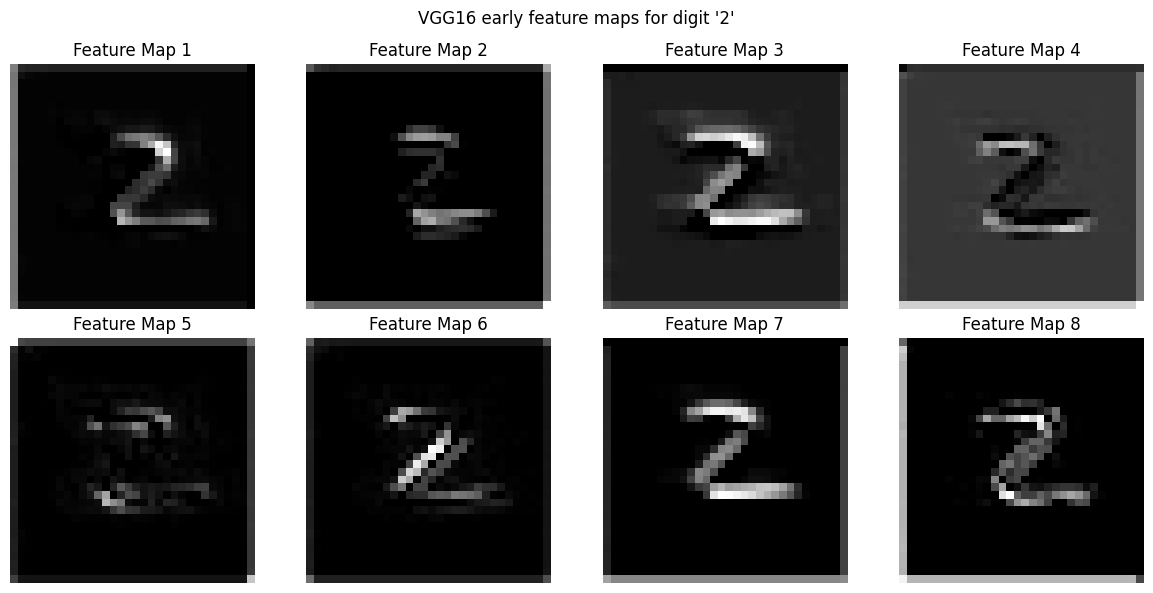

In [14]:
feature_model = models.vgg16(weights=models.VGG16_Weights.DEFAULT).to(device)
feature_model.eval()

sample_image, sample_label = test_dataset[0]
input_image = sample_image.unsqueeze(0).to(device)

with torch.no_grad():
    # Pass the image through the first 5 layers of VGG16 to see early feature maps
    feature_maps = feature_model.features[:5](input_image)

feature_maps = feature_maps.cpu()

plt.figure(figsize=(12, 6))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(feature_maps[0, i], cmap="gray")
    plt.title(f"Feature Map {i + 1}")
    plt.axis("off")
plt.suptitle(f"VGG16 early feature maps for digit '{classes[sample_label]}'")
plt.tight_layout()
plt.show()

### Hyperparameters
The same batch size and number of epochs are used for all three models for a fair comparison, following the research paper's evaluation setup.

In [15]:
EPOCHS = 5
LEARNING_RATE_CUSTOM_CNN   = 0.001
LEARNING_RATE_FROZEN_VGG   = 0.001
LEARNING_RATE_FINETUNE_VGG = 0.0001

print("Batch size:", BATCH_SIZE)
print("Epochs:", EPOCHS)
print("Custom CNN learning rate:", LEARNING_RATE_CUSTOM_CNN)
print("Frozen VGG16 learning rate:", LEARNING_RATE_FROZEN_VGG)
print("Fine-Tuned VGG16 learning rate:", LEARNING_RATE_FINETUNE_VGG)
print("Optimizer: Adam")
print("Loss function: CrossEntropyLoss")

Batch size: 32
Epochs: 5
Custom CNN learning rate: 0.001
Frozen VGG16 learning rate: 0.001
Fine-Tuned VGG16 learning rate: 0.0001
Optimizer: Adam
Loss function: CrossEntropyLoss


### Training and Validation Functions

In [16]:
def run_epoch(model, loader, criterion, optimizer=None):
    """Run one epoch. If an optimizer is given the model trains; otherwise it only evaluates."""
    model.train() if optimizer is not None else model.eval()

    running_loss, correct, total = 0.0, 0, 0

    with torch.set_grad_enabled(optimizer is not None):
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            if optimizer is not None:
                optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            if optimizer is not None:
                loss.backward()
                optimizer.step()

            running_loss += loss.item() * labels.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    return running_loss / total, 100.0 * correct / total


def train_model(model, train_loader, val_loader, epochs, learning_rate):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=learning_rate
    )

    history = {"train_loss": [], "train_accuracy": [], "val_loss": [], "val_accuracy": []}
    start_time = time.time()

    for epoch in range(epochs):
        train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = run_epoch(model, val_loader, criterion)

        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_acc)

        print(f"Epoch {epoch + 1}/{epochs} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    training_time = time.time() - start_time
    return history, training_time

### Train Custom CNN

In [17]:
custom_history, custom_time = train_model(
    custom_cnn, train_loader, val_loader, EPOCHS, LEARNING_RATE_CUSTOM_CNN
)

Epoch 1/5 | Train Loss: 1.4452 | Train Acc: 48.34% | Val Loss: 2.9423 | Val Acc: 19.30%
Epoch 2/5 | Train Loss: 0.8159 | Train Acc: 73.42% | Val Loss: 1.9787 | Val Acc: 38.63%
Epoch 3/5 | Train Loss: 0.5697 | Train Acc: 82.14% | Val Loss: 3.2986 | Val Acc: 36.25%
Epoch 4/5 | Train Loss: 0.4412 | Train Acc: 86.36% | Val Loss: 4.4017 | Val Acc: 31.21%
Epoch 5/5 | Train Loss: 0.3417 | Train Acc: 89.58% | Val Loss: 1.7978 | Val Acc: 48.59%


### Train Frozen VGG16

In [18]:
frozen_history, frozen_time = train_model(
    frozen_vgg, train_loader, val_loader, EPOCHS, LEARNING_RATE_FROZEN_VGG
)

Epoch 1/5 | Train Loss: 1.0098 | Train Acc: 73.81% | Val Loss: 0.3221 | Val Acc: 90.60%
Epoch 2/5 | Train Loss: 0.8042 | Train Acc: 82.62% | Val Loss: 0.3109 | Val Acc: 91.65%
Epoch 3/5 | Train Loss: 0.7143 | Train Acc: 84.94% | Val Loss: 0.2886 | Val Acc: 92.14%
Epoch 4/5 | Train Loss: 0.5699 | Train Acc: 87.46% | Val Loss: 0.2483 | Val Acc: 93.04%
Epoch 5/5 | Train Loss: 0.5244 | Train Acc: 88.39% | Val Loss: 0.2565 | Val Acc: 93.13%


### Train Fine-Tuned VGG16

In [19]:
finetune_history, finetune_time = train_model(
    finetune_vgg, train_loader, val_loader, EPOCHS, LEARNING_RATE_FINETUNE_VGG
)

Epoch 1/5 | Train Loss: 0.2478 | Train Acc: 92.11% | Val Loss: 0.1087 | Val Acc: 96.60%
Epoch 2/5 | Train Loss: 0.0689 | Train Acc: 97.92% | Val Loss: 0.0544 | Val Acc: 98.39%
Epoch 3/5 | Train Loss: 0.0358 | Train Acc: 98.90% | Val Loss: 0.1206 | Val Acc: 97.53%
Epoch 4/5 | Train Loss: 0.0253 | Train Acc: 99.33% | Val Loss: 0.0502 | Val Acc: 98.98%
Epoch 5/5 | Train Loss: 0.0362 | Train Acc: 99.05% | Val Loss: 0.1968 | Val Acc: 95.73%


## Task 3: Model Evaluation and Performance Comparison

**Instructions:**

1. Evaluate all three trained models on the held-out test set using: **Accuracy, Precision, Recall, F1-score, Confusion Matrix**.
2. Compare the results with those reported in the research paper.
3. Identify potential weaknesses and suggest improvements.

**Deliverables (produced by the cells below):**
- Performance metrics summary table.
- Graphs/plots showing model accuracy and loss trends.
- Comparison with research paper results (discussed below).
- Discussion on model performance and areas for improvement.

### Evaluate the Models on the Test Set

In [20]:
def evaluate_model(model, loader):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())

    return {
        "accuracy":  accuracy_score(all_labels, all_preds) * 100,
        "precision": precision_score(all_labels, all_preds, average="macro", zero_division=0),
        "recall":    recall_score(all_labels, all_preds, average="macro", zero_division=0),
        "f1":        f1_score(all_labels, all_preds, average="macro", zero_division=0),
        "predictions": all_preds,
        "labels": all_labels
    }

custom_results   = evaluate_model(custom_cnn, test_loader)
frozen_results   = evaluate_model(frozen_vgg, test_loader)
finetune_results = evaluate_model(finetune_vgg, test_loader)

print("Custom CNN Test Accuracy:      ", custom_results["accuracy"])
print("Frozen VGG16 Test Accuracy:    ", frozen_results["accuracy"])
print("Fine-Tuned VGG16 Test Accuracy:", finetune_results["accuracy"])

Custom CNN Test Accuracy:       48.08286951144094
Frozen VGG16 Test Accuracy:     93.5374149659864
Fine-Tuned VGG16 Test Accuracy: 95.91836734693877


### Count Model Parameters
Total parameters show model complexity/size; trainable parameters show how much of the model is actually updated during training.

In [21]:
def count_total_parameters(model):
    return sum(p.numel() for p in model.parameters())

def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

models_to_compare = {
    "Custom CNN": custom_cnn,
    "Frozen VGG16": frozen_vgg,
    "Fine-Tuned VGG16": finetune_vgg
}

parameter_info = {
    name: {
        "total": count_total_parameters(model),
        "trainable": count_trainable_parameters(model)
    }
    for name, model in models_to_compare.items()
}

parameter_info

{'Custom CNN': {'total': 111498, 'trainable': 111498},
 'Frozen VGG16': {'total': 134301514, 'trainable': 119586826},
 'Fine-Tuned VGG16': {'total': 134301514, 'trainable': 126666250}}

### Confusion Matrix
The confusion matrix below is shown for whichever model achieved the highest test accuracy.

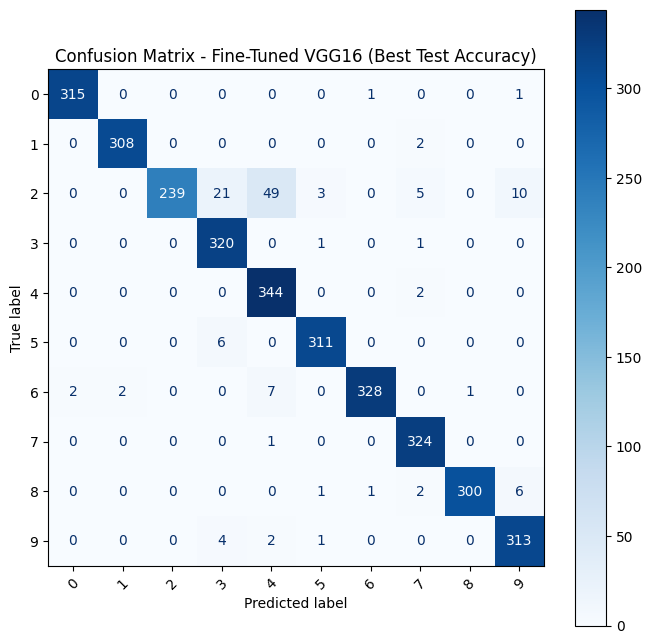

In [22]:
result_dict = {
    "Custom CNN": custom_results,
    "Frozen VGG16": frozen_results,
    "Fine-Tuned VGG16": finetune_results
}

best_model_name = max(result_dict, key=lambda name: result_dict[name]["accuracy"])
best_results = result_dict[best_model_name]

cm = confusion_matrix(best_results["labels"], best_results["predictions"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
plt.title(f"Confusion Matrix - {best_model_name} (Best Test Accuracy)")
plt.show()

### Final Comparison Table

In [23]:
comparison = pd.DataFrame({
    "Model": ["Custom CNN", "Frozen VGG16", "Fine-Tuned VGG16"],
    "Accuracy (%)": [
        custom_results["accuracy"], frozen_results["accuracy"], finetune_results["accuracy"]
    ],
    "Precision": [
        custom_results["precision"], frozen_results["precision"], finetune_results["precision"]
    ],
    "Recall": [
        custom_results["recall"], frozen_results["recall"], finetune_results["recall"]
    ],
    "F1-Score": [
        custom_results["f1"], frozen_results["f1"], finetune_results["f1"]
    ],
    "Training Time (s)": [custom_time, frozen_time, finetune_time],
    "Total Parameters": [
        parameter_info["Custom CNN"]["total"],
        parameter_info["Frozen VGG16"]["total"],
        parameter_info["Fine-Tuned VGG16"]["total"]
    ],
    "Trainable Parameters": [
        parameter_info["Custom CNN"]["trainable"],
        parameter_info["Frozen VGG16"]["trainable"],
        parameter_info["Fine-Tuned VGG16"]["trainable"]
    ]
})

comparison

,Model,Accuracy (%),Precision,Recall,F1-Score,Training Time (s),Total Parameters,Trainable Parameters
0,Custom CNN,48.082870,0.800733,0.489235,0.469389,105.196496,111498,111498
1,Frozen VGG16,93.537415,0.938088,0.935650,0.935276,218.358542,134301514,119586826
2,Fine-Tuned VGG16,95.918367,0.963698,0.959470,0.958687,236.879410,134301514,126666250


### Training and Validation Accuracy Curves

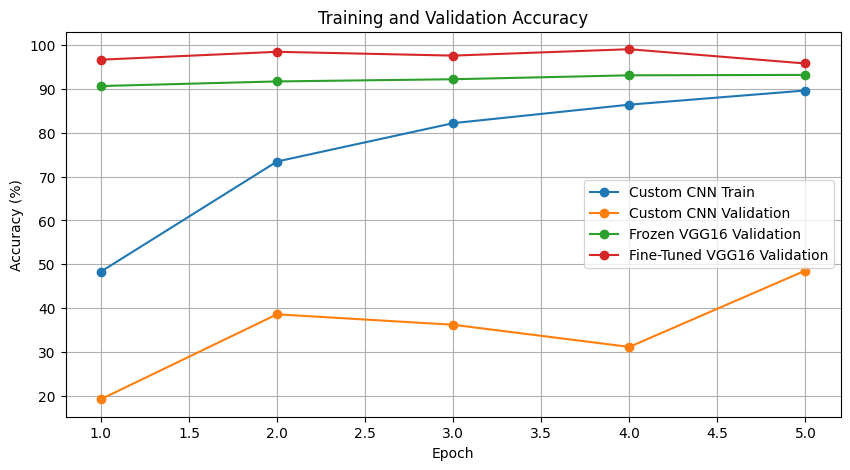

In [24]:
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs_range, custom_history["train_accuracy"], marker="o", label="Custom CNN Train")
plt.plot(epochs_range, custom_history["val_accuracy"], marker="o", label="Custom CNN Validation")
plt.plot(epochs_range, frozen_history["val_accuracy"], marker="o", label="Frozen VGG16 Validation")
plt.plot(epochs_range, finetune_history["val_accuracy"], marker="o", label="Fine-Tuned VGG16 Validation")

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid()
plt.show()

### Training and Validation Loss Curves

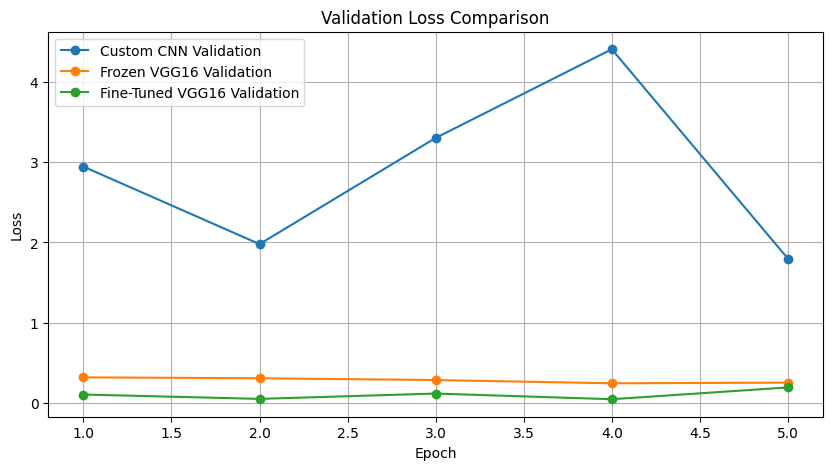

In [25]:
plt.figure(figsize=(10, 5))
plt.plot(epochs_range, custom_history["val_loss"], marker="o", label="Custom CNN Validation")
plt.plot(epochs_range, frozen_history["val_loss"], marker="o", label="Frozen VGG16 Validation")
plt.plot(epochs_range, finetune_history["val_loss"], marker="o", label="Fine-Tuned VGG16 Validation")

plt.title("Validation Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

### Sample Prediction

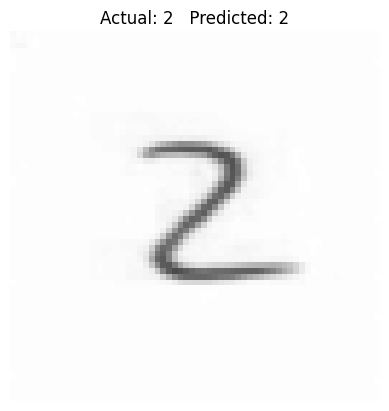

In [26]:
def predict_image(model, dataset, index):
    model.eval()
    image, actual_label = dataset[index]
    input_image = image.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_image)
        _, predicted_label = torch.max(output, 1)

    plt.imshow(denormalize(image.cpu()))
    plt.title(
        f"Actual: {classes[actual_label]}   "
        f"Predicted: {classes[predicted_label.item()]}"
    )
    plt.axis("off")
    plt.show()

best_model = models_to_compare[best_model_name]
predict_image(best_model, test_dataset, 0)

## Comparison with the Research Paper

- **Our implementation:** Real-world **Handwritten Digits (0–9)** image dataset, comparing Custom CNN, Frozen VGG16, and Fine-Tuned VGG16.
- **Research paper:** Compared the same three learning paradigms across five visual datasets (`arXiv:2601.02246`).
- **Similarity:** Both studies train/evaluate a custom CNN, a frozen pre-trained feature extractor, and a fine-tuned pre-trained model using identical data splits and metrics for a fair comparison.
- **Difference:** The paper reports results averaged over five datasets from different visual domains, while this notebook reports results on a single real digit-image dataset downloaded from Kaggle.
- **Research paper conclusion:** Fine-tuned transfer learning achieved the strongest predictive performance overall, while the custom CNN gave a better efficiency–accuracy trade-off (fewer parameters, faster training).
- **Our conclusion:** *(Fill this in after running all cells above)* — state, using the numbers in the comparison table, which of the three models achieved the highest accuracy/F1-score on the digit dataset, and whether this matches the paper's finding.

---

## Advantages and Limitations

### Custom CNN
- **Advantages:** Small, simple, fast to train, and easy to understand; very few parameters.
- **Limitations:** Learns all features from scratch, so it may need more data/epochs to reach high accuracy.

### Frozen VGG16
- **Advantages:** Reuses powerful features learned from ImageNet; only the final classifier layer is trained, so training is fast.
- **Limitations:** The frozen convolutional features were learned on natural photographs, not handwritten digits, so they may not adapt perfectly to this dataset.

### Fine-Tuned VGG16
- **Advantages:** Combines pre-trained knowledge with adaptation to our digit dataset; typically the most accurate of the three.
- **Limitations:** More parameters are trainable, so it is more computationally expensive and needs a carefully chosen (small) learning rate.

---

## Conclusion

In this practical, three approaches were compared on the **Handwritten Digits (0–9)** dataset:
1. Custom CNN trained from scratch.
2. Pre-trained VGG16 used as a frozen feature extractor.
3. Fine-Tuned VGG16 transfer learning.

The models were evaluated using accuracy, precision, recall, F1-score, a confusion matrix, training time, and parameter counts (see the *Final Comparison Table* above).

**What I learned:** *(Write 3–4 sentences here after running the notebook — e.g., how a CNN is built from scratch, how pre-trained models reuse learned image features, how fine-tuning adapts higher-level features to a new dataset, and how the three approaches compare on accuracy vs. training cost/parameter count.)*

---

## Declaration

I, NIKHEEL C K , GUNJAN B, confirm that the work submitted in this assignment is my own and has been completed following academic integrity guidelines. The code is uploaded on my GitHub repository account, and the repository link is provided below:

GitHub Repository Link: [Practicle No 1](https://github.com/Nikheel108/TY_GEN_AI_LAB_WORK_FOR_CLG/tree/main/Practicle%20no%201)


---

## Submission Checklist

✔ Research paper details and summary

✔ Code file (Python Notebook)

✔ Dataset or link to the dataset

✔ Visualizations (sample images, feature maps, accuracy/loss curves, confusion matrix)

✔ Screenshots of model performance metrics

✔ Readme File

✔ Comparison with research paper results